# Predicting Crop Yields in Indian States for Sustainable Agriculture

In [1]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import matplotlib.pyplot as plt

In [2]:
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

In [3]:
df_raw = pd.read_csv("crop_yield.csv")
df_raw.head(3)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333


In [4]:
df_raw.shape

(19689, 10)

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [6]:
df_raw.dtypes

Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

In [7]:
df_raw.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [8]:
# Total number of duplicate rows
duplicates = df_raw.duplicated()
print(duplicates.sum()) 

0


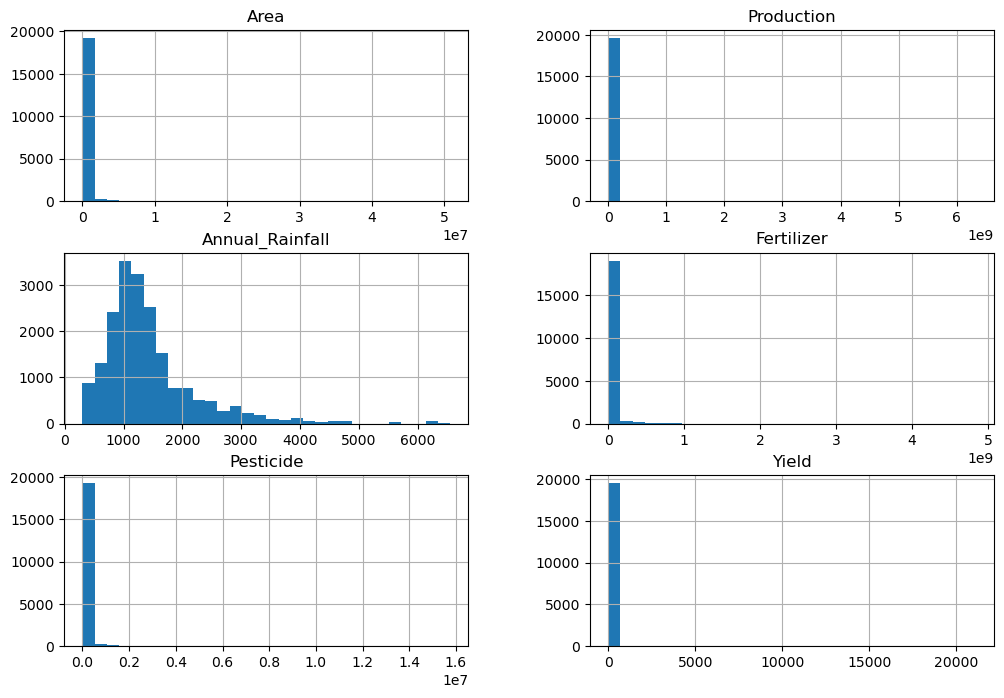

In [9]:
# Distribution of numerical features
num_cols = ["Area", "Production", "Annual_Rainfall", "Fertilizer", "Pesticide", "Yield"]
df_raw[num_cols].hist(bins=30, figsize=(12,8))
plt.show()

## conclusion of above graphs :
->Area col : Most farms in the dataset have small land area (maybe a few hectares). A few records have very large farm areas → these are outliers that dominate the axis scale.

-> Same with other column (production , fertilizer , pesticides, yield)

->Annual_Rainfall col : the shape looks roughly normal, centered around ~1200–1400. the right tail extends up beyond 4000–6000 → meaning there are some years/locations with unusually high rainfall (outliers)

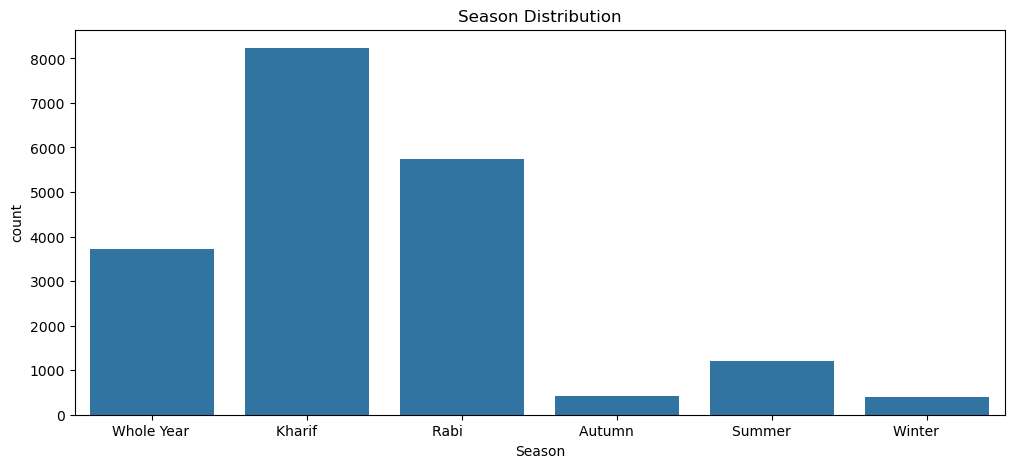

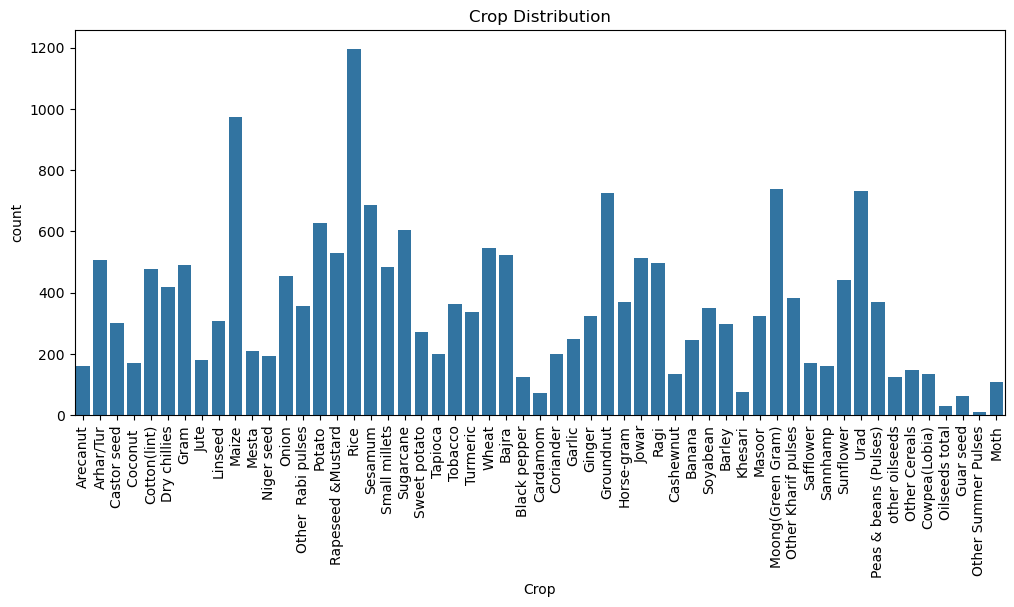

In [ ]:
#Count plots for categorical features
plt.figure(figsize=(12,5))
sns.countplot(data=df_raw, x="Season")
plt.title("Season Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(data=df_raw, x="Crop")
plt.xticks(rotation=90)
plt.title("Crop Distribution") 
plt.show()



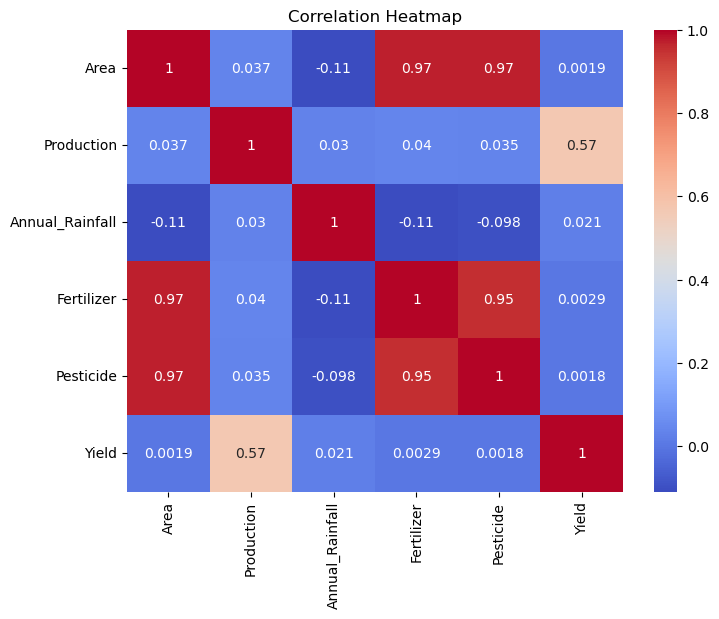

In [11]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_raw[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# transforming ONLY numeric features (cap + log1p)
num_caplog_cols = ["Area", "Annual_Rainfall", "Fertilizer", "Pesticide"]

# keeping Crop_Year as numeric (no label encoding, no log) because it's a time-based feature
maybe_num_cols = ["Crop_Year"]

# categorical columns present in your file
candidate_cats = ["Season", "Crop", "State"]
cat_cols = [c for c in candidate_cats if c in df_raw.columns]

target_col = "Yield"
drop_leakage = ["Production"]  # remove from features as including productio will overfit our model as yield=production/Area

In [13]:
# Encoding categorical variables
#Building categorical levels (so we can encode consistently in Streamlit)
cat_levels = {col: sorted(df_raw[col].dropna().astype(str).unique().tolist()) for col in cat_cols}

def encode_categories(df, levels_dict):
    df_enc = df.copy()
    for col, levels in levels_dict.items():
        lut = {v: i for i, v in enumerate(levels)}
        df_enc[col] = df_enc[col].astype(str).map(lut).fillna(-1).astype(int)
    return df_enc

In [14]:
# Apply capping + log to selected numeric features (NOT the target)
df_proc = df_raw.copy()
caps = {}

for col in num_caplog_cols:
    lower = df_proc[col].quantile(0.01)
    upper = df_proc[col].quantile(0.99)
    caps[col] = {"lower": float(lower), "upper": float(upper)}
    df_proc[col] = df_proc[col].clip(lower, upper)
    df_proc[col] = np.log1p(df_proc[col])  # log(1+x) only for features

# Encode categoricals
df_proc = encode_categories(df_proc, cat_levels)



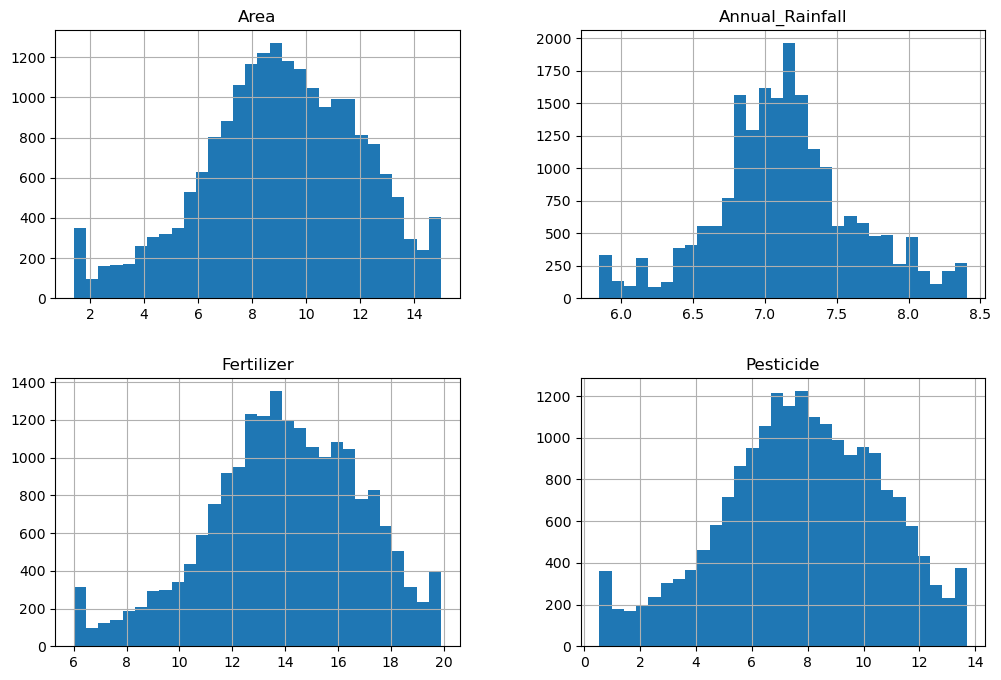

In [15]:
num_cols = ["Area", "Annual_Rainfall", "Fertilizer", "Pesticide"]
df_proc[num_cols].hist(bins=30, figsize=(12,8))
plt.show()

In [16]:
# Build X and y (y is log1p of RAW Yield; we did NOT cap/log it above)
y = np.log1p(df_raw[target_col].values)
X = df_proc.drop(columns=[c for c in [target_col] + drop_leakage if c in df_proc.columns])

print("X shape:", X.shape, "| y shape:", y.shape)
X.head(3)


X shape: (19689, 8) | y shape: (19689,)


,Crop,Crop_Year,Season,State,Area,Annual_Rainfall,Fertilizer,Pesticide
0,0,1997,4,2,11.209317,7.626765,15.764969,10.038164
1,1,1997,1,2,8.800566,7.626765,13.356082,7.629718
2,8,1997,1,2,6.680855,7.626765,11.235277,5.512461


In [17]:
y


array([0.58561039, 0.5367476 , 0.21376639, ..., 0.82636602, 0.0165293 ,
       0.816169  ])

In [18]:
#RandomizedSearchCV (tuning Random Forest)
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 15, 20, 25, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,          # make 10 for quick test; raise to 30–50 if you have time
    cv=kf,
    scoring="r2",
    verbose=2,
    n_jobs=-1,
    refit=True
)

rs.fit(X, y)
print("Best Params:", rs.best_params_)
print("Best CV R²:", rs.best_score_)
best_model = rs.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40}
Best CV R²: 0.9216934103538232


In [19]:
#Sanity check CV with the tuned model
cv_r2 = cross_val_score(best_model, X, y, cv=kf, scoring="r2")
cv_rmse = np.sqrt(-cross_val_score(best_model, X, y, cv=kf, scoring="neg_mean_squared_error"))
print("CV R²:", cv_r2, "Mean:", cv_r2.mean())
print("CV RMSE:", cv_rmse, "Mean:", cv_rmse.mean())

CV R²: [0.92648864 0.90567177 0.91574339 0.93463312 0.92593013] Mean: 0.9216934103538232
CV RMSE: [0.30435567 0.33451973 0.33477594 0.29209124 0.31837799] Mean: 0.31682411487440987


In [20]:
#Save model + preprocessing artifacts (for Streamlit)
joblib.dump(best_model, "models/best_model_rf.joblib")

artifacts = {
    "cat_cols": cat_cols,
    "cat_levels": cat_levels,                  # for mapping text -> index
    "num_caplog_cols": num_caplog_cols,        # features capped+logged
    "maybe_num_cols": maybe_num_cols,          # kept raw
    "caps": caps,                              # per-column lower/upper
    "feature_order": X.columns.tolist(),       # exact order expected by model
    "drop_leakage": drop_leakage,              # ['Production']
    "target": {"name": target_col, "log1p": True}
}
with open("artifacts/preprocessing.json", "w") as f:
    json.dump(artifacts, f, indent=2)

print("Saved -> models/best_model_rf.joblib  &  artifacts/preprocessing.json")


Saved -> models/best_model_rf.joblib  &  artifacts/preprocessing.json


In [21]:
#  Helper to invert predictions to original Yield (useful to report metrics)
def predict_yield_original(model, X_matrix):
    y_log = model.predict(X_matrix)
    return np.expm1(y_log) # exact inverse of np.log1p(x)

In [22]:
# Example overall check
y_pred_orig = predict_yield_original(best_model, X)
rmse_orig = np.sqrt(mean_squared_error(df_raw[target_col].values, y_pred_orig))
r2_orig = r2_score(df_raw[target_col].values, y_pred_orig)
print(f"Original-scale RMSE: {rmse_orig:.4f} | R²: {r2_orig:.4f}")

Original-scale RMSE: 231.9531 | R²: 0.9303
